<div style="display: flex; align-items: center; padding: 20px; background-color: #f0f2f6; border-radius: 10px; border: 2px solid #007bff;">
    <img src="../logo.png" style="width: 80px; height: auto; margin-right: 20px;">
    <div style="flex: 1; text-align: left;">
    <h1 style="color: #007bff; margin-bottom: 5px;">GLY 6739.017S26: Computational Seismology</h1>
    <h3 style="color: #666;">Notebook 80: Reading an SDS archive over Samba</h3>
    <p style="color: red;"><i>Glenn Thompson | Spring 2026</i></p>
    </div>
</div>

This notebook reads continuous waveform data for **AV.RSO..\*** from an SDS archive using ObsPy’s filesystem client, then generates **daily helicorder (dayplot) plots**.

The SDS archive format is described at: https://www.seiscomp.de/seiscomp3/doc/applications/slarchive/SDS.html

SDS layout expected (SeisComP/SLArchive convention):

```
<SDS_ROOT>/<YEAR>/<NET>/<STA>/<CHAN>.<TYPE>/<NET>.<STA>.<LOC>.<CHAN>.<TYPE>.<YEAR>.<JJJ>
```

This notebook imports DATA_ROOT from set_samba_data_root, which:
- detects your operating system (Windows, MacOS, Linux)
- sets DATA_ROOT to the default mount point of 10.246.31.49 on your operating system
    - Z:/ on Windows
    - /Volumes/classdata on MacOS



In [2]:
from set_samba_data_root import DATA_ROOT

from obspy import UTCDateTime
from obspy.clients.filesystem.sds import Client

# -------------------------
# User settings
# -------------------------
SDS_ROOT = DATA_ROOT / "SDS_Alaska"   # <-- default for this course
NET = "AV"
STA = "RSO"
LOC = ""
CHA = "*"   # all channels

# Date range (inclusive start, exclusive end)
t0 = UTCDateTime("2009-03-20T00:00:00")
t1 = UTCDateTime("2009-03-24T00:00:00")

print("SDS_ROOT:", SDS_ROOT)
print("Date range:", t0, "to", t1)

# Create SDS client
client = Client(str(SDS_ROOT))


SDS_ROOT: /Volumes/classdata/SDS_Alaska
Date range: 2009-03-20T00:00:00.000000Z to 2009-03-24T00:00:00.000000Z


## Make dayplots ("helicorder" plots)

We:
1. Read one day (00:00–24:00) for AV.RSO..\*
2. Merge segments (keeps gaps)
3. Plot one helicorder per channel as a PNG


In [4]:
from obspy import Stream
stream_master = Stream()

import numpy as np
# Loop through days, read, and plot
day = UTCDateTime(t0.date)  # snap to 00:00 of the start date
while day < t1:
    print(f"\n=== {day.date} ===")
    day_end = day + 24 * 3600
    st = client.get_waveforms(NET, STA, LOC, CHA, day, day_end)

    # Note that each MiniSEED file contains lots of MiniSEED segments
    # Each is read in as a separate Trace
    #print(st)
    print(st.__str__(extended=True))

    # Now we can merge
    st.merge(method=1, fill_value='interpolate')

    # Now we have 1 Trace per component day
    # Plot helicorder ('dayplot') for the Z-component only
    # RSO is an analog telemetred short-period seismometer
    # Data are 12-bit, i.e. in the range [-2048, 2048] but has large spikes up to 1e8
    # so we clip
    for tr in st:
        tr.data = np.clip(tr.data, -2048, 2048)

        # append to the stream_master so we have it for later
        stream_master.append(tr.copy())

        # helicorder plot 
        #tr.plot(type="dayplot", vertical_scaling_range=2048)

    day += 24 * 3600 # add one day to this UTCDateTime

print("\nDone.")



=== 2009-03-20 ===
41 Trace(s) in Stream:
AV.RSO..EHZ | 2009-03-20T00:00:00.001000Z - 2009-03-20T00:30:53.361000Z | 100.0 Hz, 185337 samples
AV.RSO..EHZ | 2009-03-20T00:30:53.390500Z - 2009-03-20T01:04:43.380500Z | 100.0 Hz, 203000 samples
AV.RSO..EHZ | 2009-03-20T01:04:43.410500Z - 2009-03-20T01:21:41.400500Z | 100.0 Hz, 101800 samples
AV.RSO..EHZ | 2009-03-20T01:21:41.420400Z - 2009-03-20T01:38:33.410400Z | 100.0 Hz, 101200 samples
AV.RSO..EHZ | 2009-03-20T01:38:33.430500Z - 2009-03-20T02:46:13.420500Z | 100.0 Hz, 406000 samples
AV.RSO..EHZ | 2009-03-20T02:46:13.470500Z - 2009-03-20T03:03:11.460500Z | 100.0 Hz, 101800 samples
AV.RSO..EHZ | 2009-03-20T03:03:11.480400Z - 2009-03-20T03:37:03.470400Z | 100.0 Hz, 203200 samples
AV.RSO..EHZ | 2009-03-20T03:37:03.500500Z - 2009-03-20T03:54:03.490500Z | 100.0 Hz, 102000 samples
AV.RSO..EHZ | 2009-03-20T03:54:03.510500Z - 2009-03-20T04:10:51.500500Z | 100.0 Hz, 100800 samples
AV.RSO..EHZ | 2009-03-20T04:10:51.520400Z - 2009-03-20T04:27:53.51

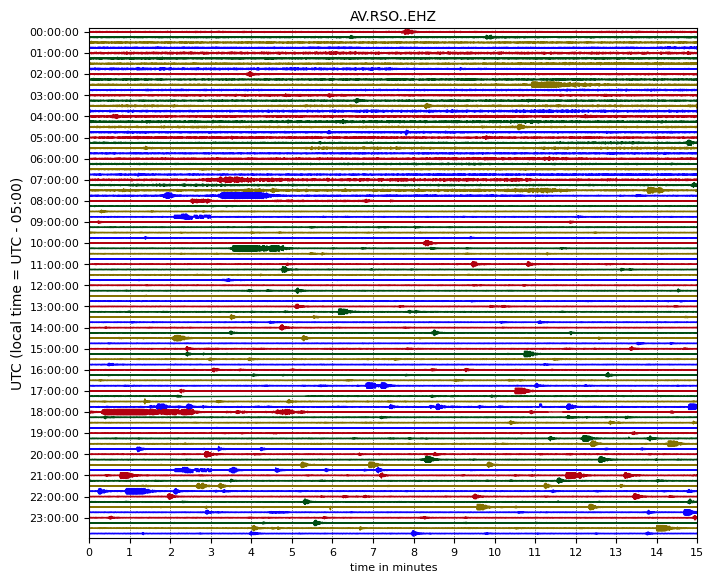

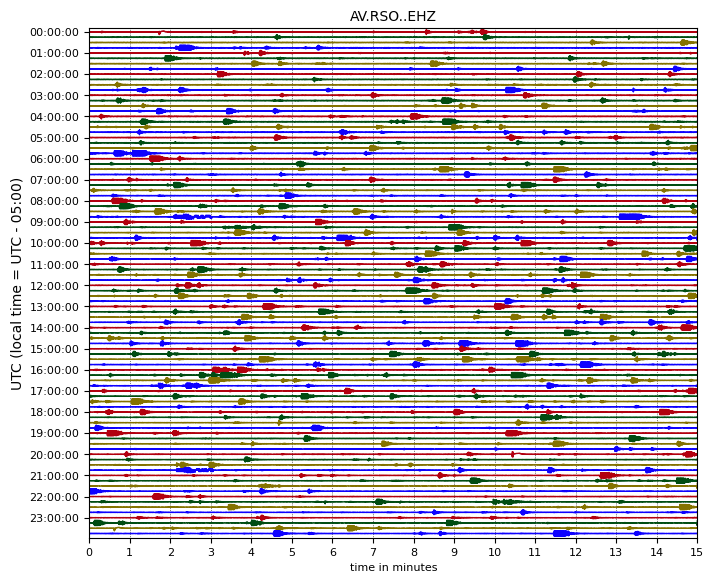

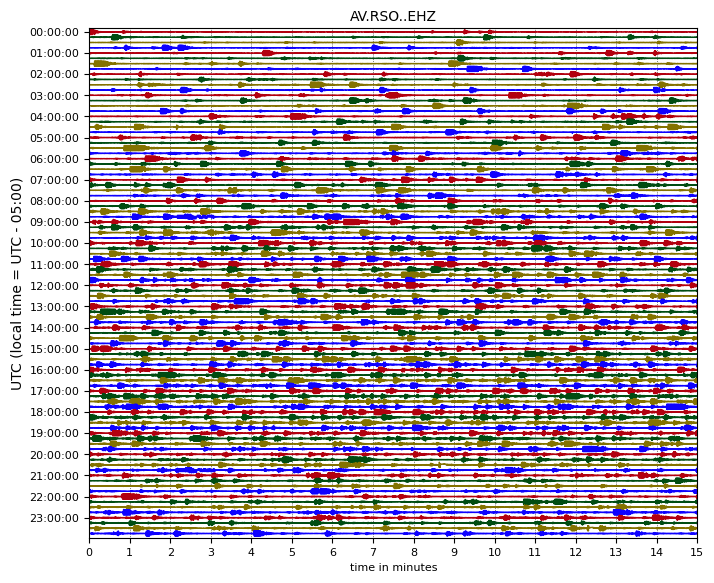

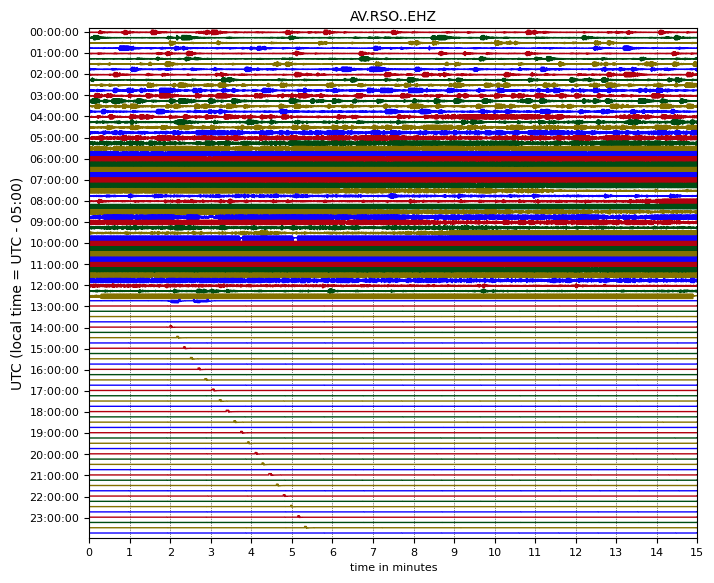

In [6]:
for tr in stream_master:
    tr.plot(type='dayplot')

# Save as a pickle file
If we want to save any Stream object from one notebook so it can be easily used in another notebook in the same workflow, we can save to a Pickle file.

Why not just save to MiniSEED?
- We absolutely could in this case, but ...
- If we had added new (non-standard) attributes to tr.stats, a Pickle file will keep them, a MiniSEED file will not

In [7]:
print(stream_master)
stream_master.write('stream_master.pkl', format='PICKLE')

4 Trace(s) in Stream:
AV.RSO..EHZ | 2009-03-20T00:00:00.001000Z - 2009-03-20T23:59:59.931000Z | 100.0 Hz, 8639994 samples
AV.RSO..EHZ | 2009-03-21T00:00:00.001100Z - 2009-03-22T00:00:00.001100Z | 100.0 Hz, 8640001 samples
AV.RSO..EHZ | 2009-03-22T00:00:00.000000Z - 2009-03-22T23:59:59.990000Z | 100.0 Hz, 8640000 samples
AV.RSO..EHZ | 2009-03-23T00:00:00.000900Z - 2009-03-24T00:00:00.000900Z | 100.0 Hz, 8640001 samples


We will read this again at the start of the next notebook